In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('data/price_history_EBL.csv')
df.head()

,id,symbol,date,open,high,low,close,traded_quantity
0,1,EBL,2025-09-28,715.0,722.0,713.0,720.00,27218
1,2,EBL,2025-09-25,705.0,716.0,702.0,714.80,21113
2,3,EBL,2025-09-24,712.0,720.0,708.3,710.00,55779
3,4,EBL,2025-09-23,705.0,719.0,701.1,712.00,48632
4,5,EBL,2025-09-21,672.0,717.0,671.0,704.96,200039


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3315 entries, 0 to 3314
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               3315 non-null   int64  
 1   symbol           3315 non-null   object 
 2   date             3315 non-null   object 
 3   open             3315 non-null   float64
 4   high             3315 non-null   float64
 5   low              3315 non-null   float64
 6   close            3315 non-null   float64
 7   traded_quantity  3315 non-null   int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 207.3+ KB


In [4]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df.set_index('date', inplace = True)


In [5]:
df.head()

,id,symbol,open,high,low,close,traded_quantity
date,,,,,,,
2011-03-20,3317,EBL,1001.0,984.0,965.0,984.0,417
2011-03-24,3316,EBL,1020.0,1039.0,1030.0,1039.0,27
2011-03-25,3315,EBL,1039.0,1059.0,1000.0,1059.0,333
2011-03-28,3314,EBL,1059.0,1038.0,960.0,998.0,324
2011-03-29,3313,EBL,998.0,979.0,899.0,959.0,1637


KeyError: 'date'

In [6]:
# select target variable

ts= df['close']
ts.head()

date
2011-03-20     984.0
2011-03-24    1039.0
2011-03-25    1059.0
2011-03-28     998.0
2011-03-29     959.0
Name: close, dtype: float64

In [7]:
df.describe()

,id,open,high,low,close,traded_quantity
count,3315.000000,3315.000000,3315.000000,3315.000000,3315.000000,3.315000e+03
mean,1658.306787,1179.763650,1194.442986,1164.392247,1179.622775,2.547511e+04
std,957.544018,803.040407,814.967379,794.605831,804.825075,4.605223e+04
min,1.000000,420.000000,423.000000,411.000000,413.000000,1.000000e+01
25%,829.500000,603.000000,610.000000,595.950000,603.000000,4.650500e+03
50%,1658.000000,750.000000,758.000000,736.000000,747.000000,1.050300e+04
75%,2486.500000,1690.000000,1710.000000,1670.000000,1690.000000,2.674250e+04
max,3317.000000,3795.000000,3920.000000,3706.000000,3795.000000,1.086498e+06


In [10]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(ts)
print("ADF Statistics: ", result[0])
print("p-value : ", result[1])

ADF Statistics:  -1.8633215771055778
p-value :  0.34950754235279724


In [9]:
ts_diff = ts.diff().dropna()

In [10]:
result = adfuller(ts_diff)
print("ADF Statistics: ", result[0])
print("p-value : ", result[1])

ADF Statistics:  -9.57852098639213
p-value :  2.190129370126165e-16


In [11]:
# ADF --> Augmented Dickey - Fuller
# ADF --> Augmented Dickey -Fuller
# ADF --> Augmented Dickey Fuller

# to check wether the timeseries has unit root or not 

In [12]:
ts = df['close']
ts

date
2011-03-20     984.00
2011-03-24    1039.00
2011-03-25    1059.00
2011-03-28     998.00
2011-03-29     959.00
               ...   
2025-09-21     704.96
2025-09-23     712.00
2025-09-24     710.00
2025-09-25     714.80
2025-09-28     720.00
Name: close, Length: 3315, dtype: float64

In [13]:
ts_diff

date
2011-03-24    55.00
2011-03-25    20.00
2011-03-28   -61.00
2011-03-29   -39.00
2011-03-30    30.00
              ...  
2025-09-21    33.86
2025-09-23     7.04
2025-09-24    -2.00
2025-09-25     4.80
2025-09-28     5.20
Name: close, Length: 3314, dtype: float64

In [14]:
from pmdarima import auto_arima

# to check which arima model to use we use pmdarima auto-arima

stepwise_fit = auto_arima(ts, d = 1, trace = True, supress_warnings = True)
print(stepwise_fit.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=33880.791, Time=3.24 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=33911.327, Time=0.17 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=33883.202, Time=0.34 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=33884.801, Time=0.43 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=33909.340, Time=0.10 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=33884.648, Time=3.56 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=33885.107, Time=3.84 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=10.45 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=33882.721, Time=4.67 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=33884.210, Time=2.38 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=33884.913, Time=2.66 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=33884.199, Time=2.44 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=33883.346, Time=7.63 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=33878.801, Time=1.68 sec
 ARIMA(1,1,2)(0,0,0)[0] 

In [15]:
from statsmodels.tsa.arima.model import ARIMA

In [24]:
model = ARIMA(ts, order = (2,1,2))
model_fit = model.fit()
print(model_fit.summary())

c:\Users\prash\anaconda3\envs\cnn\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\prash\anaconda3\envs\cnn\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\prash\anaconda3\envs\cnn\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                 3315
Model:                 ARIMA(2, 1, 2)   Log Likelihood              -16934.401
Date:                Wed, 10 Dec 2025   AIC                          33878.801
Time:                        15:39:28   BIC                          33909.331
Sample:                             0   HQIC                         33889.727
                               - 3315                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6605      0.186      3.553      0.000       0.296       1.025
ar.L2         -0.5040      0.092     -5.458      0.000      -0.685      -0.323
ma.L1         -0.5691      0.187     -3.045      0.0

In [18]:
import joblib 

joblib.dump(model, 'EBL_arima_model.pkl')

['EBL_arima_model.pkl']

In [1]:
# opg stands for overall population group

# which indicates the varinace is calculated from entrire population not just from a sample

In [19]:
forecast_200 = model_fit.forecast(steps = 200)
forecast_200

c:\Users\prash\anaconda3\envs\cnn\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\prash\anaconda3\envs\cnn\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


3314    1.322029
3315   -0.847767
3316    0.747833
3317   -0.894364
3318    0.736263
          ...   
3509   -0.454810
3510    0.297963
3511   -0.451785
3512    0.294949
3513   -0.448784
Name: predicted_mean, Length: 200, dtype: float64

In [20]:
last_date = df.index[-1]
future_dates = pd.date_range(start = last_date, periods = 201, freq = 'B')[1:]
forecast_200.index = future_dates

In [23]:
combined = pd.concat([df, forecast_200], axis = 0)

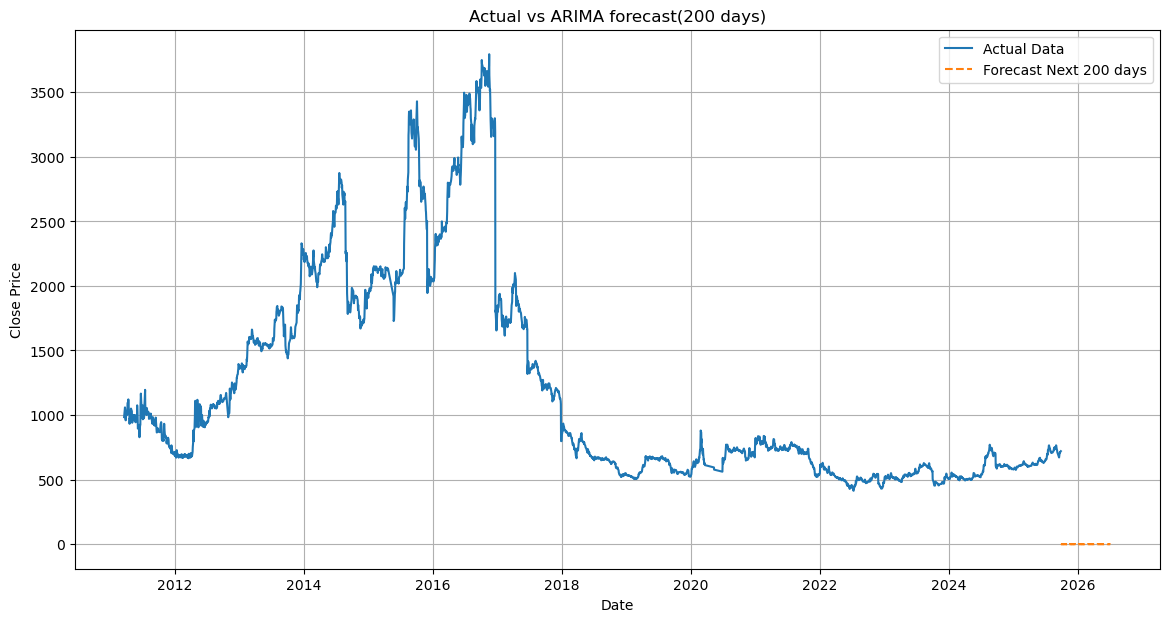

In [26]:
plt.figure(figsize = (14,7))

plt.plot(df['close'], label = 'Actual Data')
plt.plot(forecast_200, label = 'Forecast Next 200 days', linestyle = '--' )
plt.title("Actual vs ARIMA forecast(200 days)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

# LSTM Model(Long short term memory)

### Best for stocks

Deep learning models allow as many columns as you want

In [9]:
from sklearn.preprocessing import MinMaxScaler

In [29]:
# LSTM has 3 gates

# forget gate --> decides what past information to discard

# input gate --> what new information to add   

# output gate --> decides what information to output at the current step

In [10]:
features = df[['open', 'high','low', 'close', 'traded_quantity']].values


scaler = MinMaxScaler(feature_range = (0,1))
scaled = scaler.fit_transform(features)

In [6]:
import joblib

joblib.dump(scaler, 'EBL_scaler.pkl')

['EBL_scaler.pkl']

In [32]:
# Prepare sequences for LSTM 

X, Y = [], []

sequence_length = 60


for i in range(sequence_length, len(scaled)):
    X.append(scaled[i-sequence_length:i]) # past 60 timesteps, all 5 features
    Y.append(scaled[i][3])                   # column 3 = 'close' (target)
    
X = np.array(X)
Y = np.array(Y)
print(X.shape, Y.shape)

(3255, 60, 5) (3255,)


In [36]:
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import LSTM, Dense 


model = Sequential([
    LSTM(64, return_sequences = True, input_shape = (60,5)),
    LSTM(32),
    Dense(1) # predicting one value : close
])


model.compile(optimizer = 'adam', loss = 'mse')

In [37]:
model.fit(X, Y, epochs = 20, batch_size= 16)

Epoch 1/20
204/204 [==============================] - 35s 71ms/step - loss: 0.0037
Epoch 2/20
204/204 [==============================] - 14s 71ms/step - loss: 7.5586e-04
Epoch 3/20
204/204 [==============================] - 15s 71ms/step - loss: 5.8034e-04
Epoch 4/20
204/204 [==============================] - 15s 72ms/step - loss: 4.6878e-04
Epoch 5/20
204/204 [==============================] - 15s 75ms/step - loss: 4.6603e-04
Epoch 6/20
204/204 [==============================] - 15s 72ms/step - loss: 4.0046e-04
Epoch 7/20
204/204 [==============================] - 15s 72ms/step - loss: 3.8515e-04
Epoch 8/20
204/204 [==============================] - 15s 71ms/step - loss: 3.2187e-04
Epoch 9/20
204/204 [==============================] - 15s 71ms/step - loss: 2.8470e-04
Epoch 10/20
204/204 [==============================] - 18s 86ms/step - loss: 3.3311e-04
Epoch 11/20
204/204 [==============================] - 17s 83ms/step - loss: 2.7049e-04
Epoch 12/20
204/204 [========================

In [38]:
# predict for last 200 days of data

# how nlp works which steps to follow? 

In [39]:
model.save('LSTM_model_EBL.h5')

In [11]:
from tensorflow.keras.models import load_model

model = load_model('LSTM_model_EBL.h5')

In [ ]:
import joblib
scaler = joblib.load('EBL_scaler.pkl')
scaled_features = scaler.transform(features)


In [14]:
future_days = 200
predictions = []

input_sequence = scaled_features[-60:].copy()
input_sequence = input_sequence.reshape(1, 60, 5)

for _ in range(future_days):
    next_close_scaled = model.predict(input_sequence)[0][0]
    predictions.append(next_close_scaled)

    next_row = input_sequence[0, -1, :].copy()
    next_row[3] = next_close_scaled

    input_sequence = np.append(input_sequence[:, 1:, :], next_row.reshape(1, 1, 5), axis = 1)
    

1/1 [==============================] - 0s 43ms/step


In [15]:
pred_close = scaler.inverse_transform(
    np.array([[0,0,0,x,0] for x in predictions])
)[:,3]


In [25]:
pred_close

array([1014.82098612, 1003.31533924,  996.59849593,  992.8612496 ,
        990.91058218,  989.997462  ,  989.66500139,  989.63929957,
        989.76171079,  989.9421275 ,  990.13181701,  990.30663979,
        990.45611352,  990.57812157,  990.67392385,  990.74745122,
        990.80228177,  990.84274954,  990.87218064,  990.89375001,
        990.90967506,  990.92187083,  990.93154681,  990.93971092,
        990.9469679 ,  990.95356974,  990.95971802,  990.96561432,
        990.97120824,  990.9764998 ,  990.98138818,  990.98597419,
        990.99020743,  990.99403751,  990.99756521,  991.00053856,
        991.00320953,  991.00572932,  991.00769475,  991.00935781,
        991.01092008,  991.01207918,  991.01328868,  991.01429659,
        991.01505253,  991.01590925,  991.01661479,  991.01696756,
        991.01752192,  991.01792508,  991.01827785,  991.01852983,
        991.01883221,  991.0188826 ,  991.01898339,  991.01908419,
        991.01918498,  991.01938656,  991.01943696,  991.01938

In [24]:
df.index


DatetimeIndex(['2011-03-20', '2011-03-24', '2011-03-25', '2011-03-28',
               '2011-03-29', '2011-03-30', '2011-03-31', '2011-04-04',
               '2011-04-05', '2011-04-06',
               ...
               '2025-09-03', '2025-09-04', '2025-09-07', '2025-09-08',
               '2025-09-18', '2025-09-21', '2025-09-23', '2025-09-24',
               '2025-09-25', '2025-09-28'],
              dtype='datetime64[ns]', name='date', length=3315, freq=None)

In [ ]:
future_days = len(pred_close)

# Get last date from index (since date is the index)
last_date = df.index[-1]    # already datetime if parsed earlier

# Generate future dates
future_dates = pd.date_range(
    start = last_date + pd.Timedelta(days=1),
    periods = future_days,
    freq='D'
)

# Create forecast dataframe
forecast_df = pd.DataFrame({
    'date': future_dates,
    'predicted_close': pred_close
})

forecast_df.set_index('date', inplace=True)

print(forecast_df)


# forecast_df --> dataframe, columns = ['date', 'predicted_close']

            predicted_close
date                       
2025-09-29       716.156807
2025-09-30       720.215805
2025-10-01       722.255396
2025-10-02       722.660048
2025-10-03       721.959573
...                     ...
2026-04-12       721.477764
2026-04-13       721.477764
2026-04-14       721.477764
2026-04-15       721.477739
2026-04-16       721.477764

[200 rows x 1 columns]


In [ ]:
forecast_df.to_csv('LSTM_200_day_forecast.csv')

In [26]:
forecast_200 = pd.read_csv('LSTM_200_day_forecast.csv')
forecast_200

,date,predicted_close
0,2025-09-29,716.156807
1,2025-09-30,720.215805
2,2025-10-01,722.255396
3,2025-10-02,722.660048
4,2025-10-03,721.959573
...,...,...
195,2026-04-12,721.477764
196,2026-04-13,721.477764
197,2026-04-14,721.477764
198,2026-04-15,721.477739


In [27]:
forecast_200.sample(5)

,date,predicted_close
81,2025-12-19,721.477739
108,2026-01-15,721.477739
116,2026-01-23,721.477764
141,2026-02-17,721.477739
143,2026-02-19,721.477764
